У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

original_ds = pd.read_csv('/content/drive/MyDrive/ML1/data/customer_segmentation_train.csv')

In [4]:
original_ds.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [5]:
original_ds.dtypes

,0
ID,int64
Gender,object
Ever_Married,object
Age,int64
Graduated,object
Profession,object
Work_Experience,float64
Spending_Score,object
Family_Size,float64
Var_1,object


In [9]:
original_ds.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [10]:
original_ds.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [11]:
# Базова статистика Work_Experience
print("\nПропусків:", original_ds['Work_Experience'].isna().sum())
print("Медіана:", original_ds['Work_Experience'].median())
print("Середнє:", original_ds['Work_Experience'].mean())

count    7239.000000
mean        2.641663
std         3.406763
min         0.000000
25%         0.000000
50%         1.000000
75%         4.000000
max        14.000000
Name: Work_Experience, dtype: float64

Пропусків: 829
Медіана: 1.0
Середнє: 2.641663213150988


In [12]:
# Work_Experience counts
print(original_ds['Work_Experience'].value_counts().sort_index())

Work_Experience
0.0     2318
1.0     2354
2.0      286
3.0      255
4.0      253
5.0      194
6.0      204
7.0      196
8.0      463
9.0      474
10.0      53
11.0      50
12.0      48
13.0      46
14.0      45
Name: count, dtype: int64


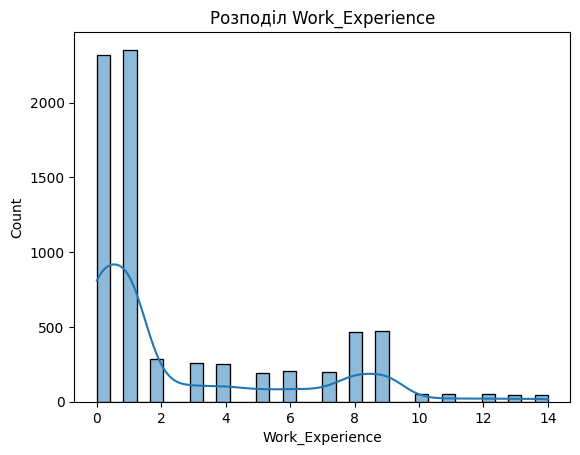

In [13]:
# Візуалізація Work_Experience
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(original_ds['Work_Experience'], kde=True)
plt.title('Розподіл Work_Experience')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# target окремо, ID викидаємо (не несе інформації для передбачення)
X = original_ds.drop(columns=['ID', 'Segmentation'])
y = original_ds['Segmentation']

In [17]:
# Групуємо колонки за способом обробки
numeric_cols = ['Age', 'Work_Experience', 'Family_Size']
binary_cols = ['Gender', 'Ever_Married', 'Graduated']
ordinal_cols = ['Spending_Score']
onehot_cols = ['Profession', 'Var_1'] # немає порядку -> OneHot

In [28]:
# Розбиваємо before препроцесинг (щоб уникнути витоку)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, # 20% as asked
    random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nБаланс класів у train:\n")
print(y_train.value_counts(normalize=True).round(4))

Train: (6454, 9) | Test: (1614, 9)

Баланс класів у train:

Segmentation
D    0.2811
A    0.2445
C    0.2442
B    0.2302
Name: proportion, dtype: float64


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# для числових колонок
numeric_cols = ['Age', 'Work_Experience', 'Family_Size']
categorical_cols = ['Gender', 'Ever_Married', 'Graduated', 'Spending_Score', 'Profession', 'Var_1']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Збираємо все разом
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train після обробки:", X_train_processed.shape)  # МАЄ бути (6454, 9)

Train після обробки: (6454, 9)


In [30]:
feature_names = preprocessor.get_feature_names_out()

print("Кількість ознак після обробки:", len(feature_names))
print(feature_names)

Кількість ознак після обробки: 9
['num__Age' 'num__Work_Experience' 'num__Family_Size' 'cat__Gender'
 'cat__Ever_Married' 'cat__Graduated' 'cat__Spending_Score'
 'cat__Profession' 'cat__Var_1']


**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [31]:
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek

In [32]:
# Категоріальні колонки після препроцесингу - на індексах 3..8
# (0,1,2 - числові Age/Work_Experience/Family_Size; далі 6 категоріальних)
cat_indices = [3, 4, 5, 6, 7, 8]

# 1. SMOTENC (up-sampling)
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_smote, y_train_smote = smote_nc.fit_resample(X_train_processed, y_train)

print("SMOTENC — розмір:", X_train_smote.shape)
print(pd.Series(y_train_smote).value_counts(), "\n")

SMOTENC — розмір: (7256, 9)
Segmentation
A    1814
B    1814
C    1814
D    1814
Name: count, dtype: int64 



In [33]:
# 2. SMOTENC-Tomek (re-sampling: up + очищення меж)
smote_tomek = SMOTETomek(
    smote=SMOTENC(categorical_features=cat_indices, random_state=42),
    random_state=42
)
X_train_smotetomek, y_train_smotetomek = smote_tomek.fit_resample(X_train_processed, y_train)

print("SMOTENC-Tomek — розмір:", X_train_smotetomek.shape)
print(pd.Series(y_train_smotetomek).value_counts())

SMOTENC-Tomek — розмір: (6078, 9)
Segmentation
D    1551
C    1546
B    1515
A    1466
Name: count, dtype: int64


**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [35]:
# Масштабуємо ПІСЛЯ SMOTE (fit на кожному train-наборі окремо, transform на test)
scaler = StandardScaler()

datasets = {
    'Original': (X_train_processed, y_train),
    'SMOTENC': (X_train_smote, y_train_smote),
    'SMOTENC-Tomek': (X_train_smotetomek, y_train_smotetomek),
}

for name, (X_tr, y_tr) in datasets.items():
    # масштабування: вчимо scaler на цьому train-наборі
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_test_scaled = scaler.transform(X_test_processed)

    # One-vs-Rest з логістичною регресією
    model = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
    model.fit(X_tr_scaled, y_tr)

    y_pred = model.predict(X_test_scaled)

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred))
    print()

===== Original =====
              precision    recall  f1-score   support

           A       0.39      0.39      0.39       394
           B       0.41      0.08      0.14       372
           C       0.47      0.64      0.54       394
           D       0.59      0.79      0.67       454

    accuracy                           0.49      1614
   macro avg       0.46      0.48      0.44      1614
weighted avg       0.47      0.49      0.45      1614


===== SMOTENC =====
              precision    recall  f1-score   support

           A       0.41      0.40      0.41       394
           B       0.37      0.14      0.21       372
           C       0.48      0.63      0.54       394
           D       0.62      0.78      0.69       454

    accuracy                           0.50      1614
   macro avg       0.47      0.49      0.46      1614
weighted avg       0.48      0.50      0.47      1614


===== SMOTENC-Tomek =====
              precision    recall  f1-score   support

      

Напишіть, яку метрику ви обрали для порівняння моделей.
Macro avg F1-score.
Accuracy витягується за рахунок впливових класів - не показник.

===
Яка модель найкраща?
Обидві вибрані моделі трохи кращі за оригінал. Можливо обрала б SMOTENC-Tomek, але тут не принциповою Для себе далі побудувала візуалізацію і  з неї видно що групи розділені дуже перемішано (слабо). Дані хрень.

===
Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?
Низька якість усіх моделей ознаки погано класифікують дані.

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundaries(X2d, y, model, ax, title):
    # сітка точок по всій площині графіка
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # передбачення моделі для кожної точки сітки -> зафарбовуємо фон
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = pd.factorize(Z)[0].reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    # самі точки даних поверх
    codes = pd.factorize(y)[0]
    ax.scatter(X2d[:, 0], X2d[:, 1], c=codes, cmap='viridis',
               edgecolors='k', s=15, linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel('PCA компонента 1')
    ax.set_ylabel('PCA компонента 2')

In [37]:
# scaler + PCA вчимо на оригінальному train, застосовуємо до всіх наборів
scaler_viz = StandardScaler().fit(X_train_processed)
pca = PCA(n_components=2, random_state=42).fit(scaler_viz.transform(X_train_processed))

def to_2d(X):
    return pca.transform(scaler_viz.transform(X))

X_train_2d = to_2d(X_train_processed)
X_smote_2d = to_2d(X_train_smote)
X_smotetomek_2d = to_2d(X_train_smotetomek)

print("Варіація, збережена 2 компонентами:", round(pca.explained_variance_ratio_.sum(), 3))

# окрема модель на кожному 2D-наборі (тільки для візуалізації меж!)
def fit_2d(X2d, y):
    m = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
    m.fit(X2d, y)
    return m

clf_orig = fit_2d(X_train_2d, y_train)
clf_smote = fit_2d(X_smote_2d, y_train_smote)
clf_smotetomek = fit_2d(X_smotetomek_2d, y_train_smotetomek)

Варіація, збережена 2 компонентами: 0.4


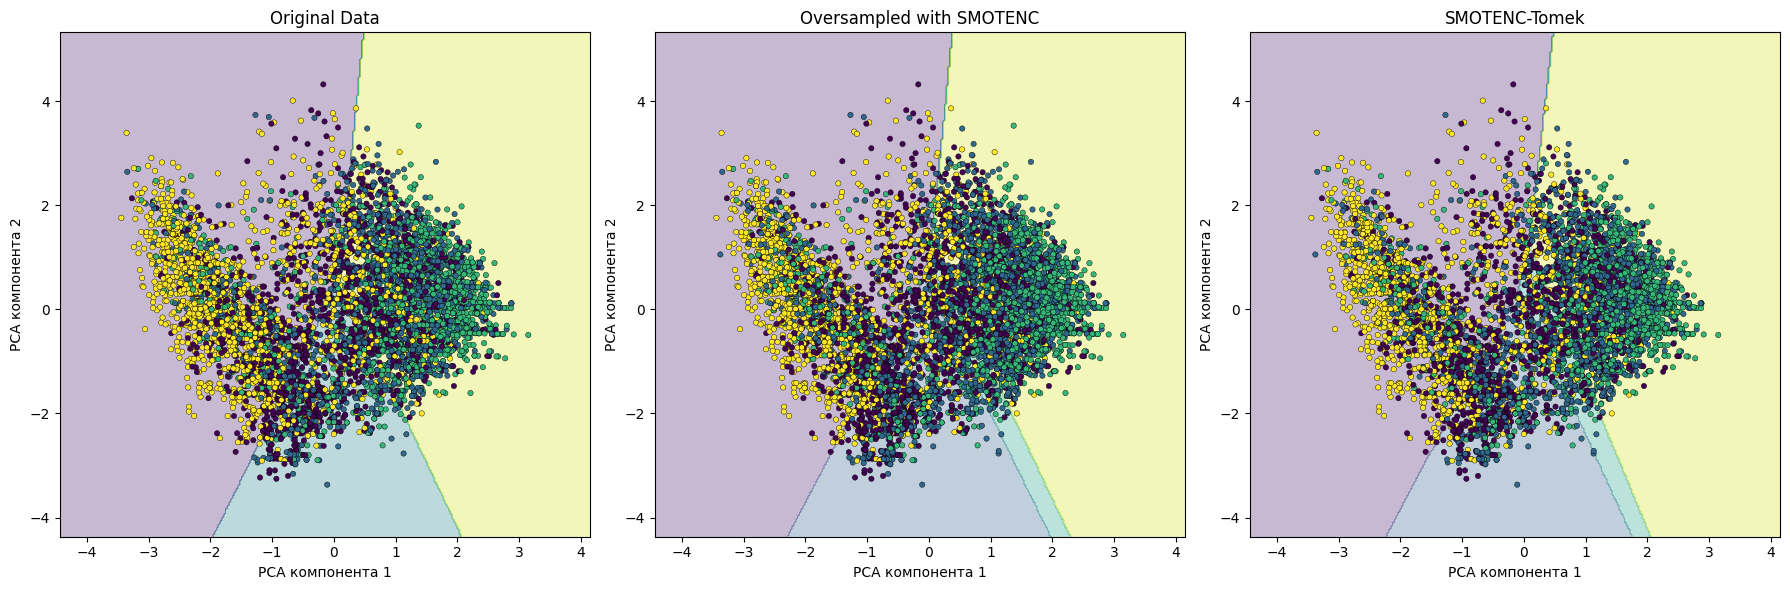

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_decision_boundaries(X_train_2d, y_train, clf_orig, axes[0], "Original Data")
plot_decision_boundaries(X_smote_2d, y_train_smote, clf_smote, axes[1], "Oversampled with SMOTENC")
plot_decision_boundaries(X_smotetomek_2d, y_train_smotetomek, clf_smotetomek, axes[2], "SMOTENC-Tomek")

plt.tight_layout()
plt.show()

класи сильно перемішані в просторі ознак, через що межі рішень майже ідентичні для Original, SMOTENC та SMOTENC-Tomek.